# RES

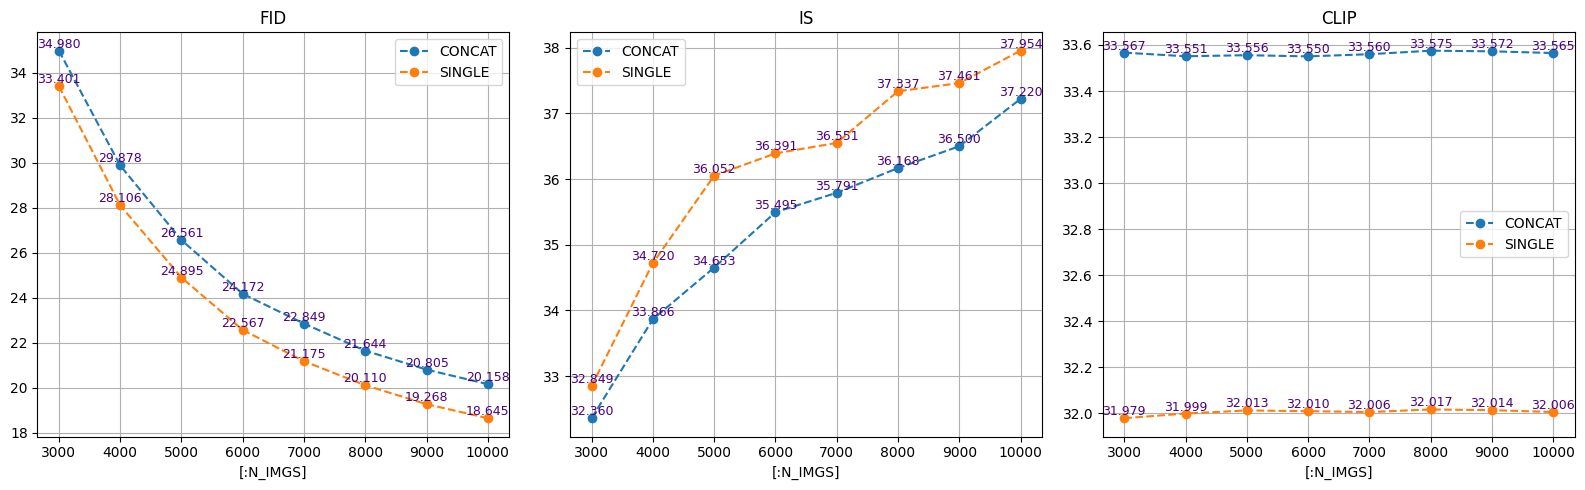

In [11]:
def plot_metrics_N(metrics_CONCAT, metrics_SINGLE):
  N_IMGS  = list(range(3000, 11000, 1000))
  metrics = ['FID', 'IS', 'CLIP']
  metrics_list_CONCAT = [[metrics_CONCAT[N]['FID'] for N in N_IMGS],
                        [metrics_CONCAT[N]['IS'] for N in N_IMGS], 
                        [metrics_CONCAT[N]['CLIP'] for N in N_IMGS]]

  metrics_list_SINGLE = [[metrics_SINGLE[N]['FID'] for N in N_IMGS],
                        [metrics_SINGLE[N]['IS'] for N in N_IMGS], 
                        [metrics_SINGLE[N]['CLIP'] for N in N_IMGS]]
  import matplotlib.pyplot as plt
  fig, ax = plt.subplots(1, 3, figsize=(16, 5))
  for m in range(3):
    ax[m].plot(N_IMGS, metrics_list_CONCAT[m], '--o', label='CONCAT')
    ax[m].plot(N_IMGS, metrics_list_SINGLE[m], '--o', label='SINGLE')
    for i, N in enumerate(N_IMGS):
      ax[m].text(N, metrics_list_CONCAT[m][i], f'{metrics_list_CONCAT[m][i]:.3f}', ha='center', va='bottom', fontsize=9, color='indigo')
      ax[m].text(N, metrics_list_SINGLE[m][i], f'{metrics_list_SINGLE[m][i]:.3f}', ha='center', va='bottom', fontsize=9, color='indigo')
    ax[m].set_xticks(N_IMGS)
    ax[m].set_xticklabels(N_IMGS)
    ax[m].set_xlabel('[:N_IMGS]')
    ax[m].set_title(metrics[m])
    ax[m].grid(True)
    ax[m].legend()
  plt.tight_layout();

metrics_CONCAT = {
  3000:  {'IS': 32.35957717895508,'FID': 34.97976303100586,'CLIP': 33.566680908203125},
  4000:  {'IS': 33.866371154785156,'FID': 29.87811851501465,'CLIP': 33.551002502441406},
  5000:  {'IS': 34.653236389160156,'FID': 26.560680389404297,'CLIP': 33.5555572509765},
  6000:  {'IS': 35.49519729614258,'FID': 24.171985626220703,'CLIP': 33.550479888916016},
  7000:  {'IS': 35.79130935668945,'FID': 22.849124908447266,'CLIP': 33.55988311767578},
  8000:  {'IS': 36.1675910949707,'FID': 21.643983840942383,'CLIP': 33.575096130371094},
  9000:  {'IS': 36.499595642089844,'FID': 20.80478858947754,'CLIP': 33.57246017456055},
  10000: {'IS': 37.22028350830078,'FID': 20.15770721435547,'CLIP': 33.56498336791992}
}

metrics_SINGLE = {
  3000:  {'IS': 32.849334716796875, 'FID': 33.40082550048828, 'CLIP': 31.97917938232422},
  4000:  {'IS': 34.720245361328125, 'FID': 28.10612678527832, 'CLIP': 31.999439239501953},
  5000:  {'IS': 36.05204391479492, 'FID': 24.8946475982666, 'CLIP': 32.012840270996094},
  6000:  {'IS': 36.39090347290039, 'FID': 22.56676483154297, 'CLIP': 32.009822845458984},
  7000:  {'IS': 36.55051040649414, 'FID': 21.17537498474121, 'CLIP': 32.00589370727539},
  8000:  {'IS': 37.33708953857422, 'FID': 20.11031723022461, 'CLIP': 32.017215728759766},
  9000:  {'IS': 37.460811614990234, 'FID': 19.268051147460938, 'CLIP': 32.01409149169922},
  10000: {'IS': 37.95423126220703, 'FID': 18.644962310791016, 'CLIP': 32.005943298339844},
}
plot_metrics_N(metrics_CONCAT, metrics_SINGLE)

# DPMS-LINEAR metrics BIAS

In [ ]:
import sys, torch
sys.path.append('/home/mdnikolaev/philurame/SDXL_METRICS/')

from lib.generate_decode import decode_vae
from main import load_pipe, load_data

pipe = load_pipe(
  solver='DPMS',
  scheduler='LINEAR',
  cacher_quantizer='NONE',
  is_optimize=False,
  add_vae=True
)

save_path = '/home/mdnikolaev/philurame/SDXL_METRICS/DATA/NONE/COCO_10/DPMS_LINEAR.pt'
gen_latents = torch.load(save_path, map_location='cpu')
gen_imgs = decode_vae(pipe, gen_latents)
del gen_latents

import gc
gc.collect()
torch.cuda.empty_cache()

In [ ]:
data = load_data('/home/mdnikolaev/philurame/SDXL_METRICS/DATA', 'COCO', 10000)

from lib.metric import metrics_registry
def _get_metrics(**kwargs):
  res_metrics = {}
  for metric_name in metrics_registry:
    if metric_name not in ['LPIPS', 'SEC_PER_IMG', 'TFLOPS']:
      metricInstance = metrics_registry[metric_name](**kwargs)
      if hasattr(metricInstance, 'to'):
        metricInstance = metricInstance.to('cpu')
      res_metrics[metric_name] = metricInstance()

      del metricInstance
      gc.collect()
      torch.cuda.empty_cache()
  return res_metrics

def get_metrics_N(N_IMGS):
  metrics=_get_metrics(
    path_ddim=None, 
    fake_imgs=gen_imgs[:N_IMGS], 
    real_imgs=data.imgs[:N_IMGS], 
    real_anns=data.anns[:N_IMGS],
    pipe=pipe, 
    nfe=10
    )
  return metrics



metrics_N = {}
for N in range(3000, 11000, 1000):
  metrics_N[N] = get_metrics_N(N)
  print('#'*50, N, '#'*50, '\n', sep='\n')
  for k, v in metrics_N[N].items():
    print(f'{k}: {v}\n', '#'*50)

# metrics_N = {
#   3000:  {'IS': 32.35957717895508,'FID': 34.97976303100586,'CLIP': 33.566680908203125},
#   4000:  {'IS': 33.866371154785156,'FID': 29.87811851501465,'CLIP': 33.551002502441406},
#   5000:  {'IS': 34.653236389160156,'FID': 26.560680389404297,'CLIP': 33.5555572509765},
#   6000:  {'IS': 35.49519729614258,'FID': 24.171985626220703,'CLIP': 33.550479888916016},
#   7000:  {'IS': 35.79130935668945,'FID': 22.849124908447266,'CLIP': 33.55988311767578},
#   8000:  {'IS': 36.1675910949707,'FID': 21.643983840942383,'CLIP': 33.575096130371094},
#   9000:  {'IS': 36.499595642089844,'FID': 20.80478858947754,'CLIP': 33.57246017456055},
#   10000: {'IS': 37.22028350830078,'FID': 20.15770721435547,'CLIP': 33.56498336791992}
# }

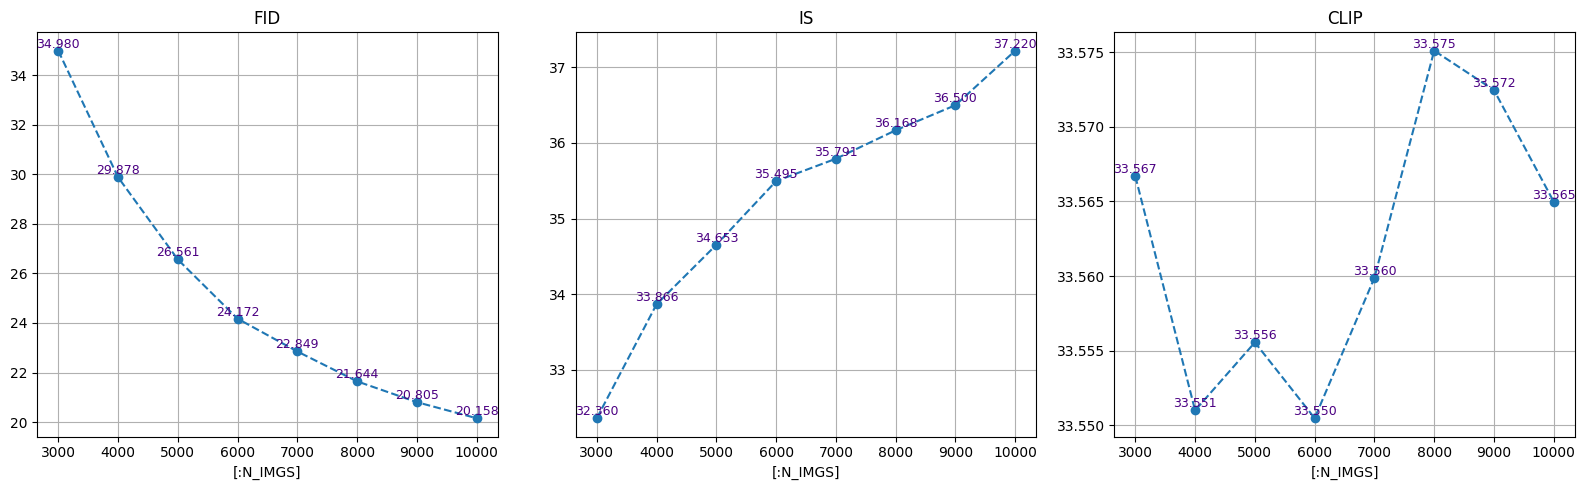

In [45]:
N_IMGS  = list(range(3000, 11000, 1000))
metrics = ['FID', 'IS', 'CLIP']
metrics_list = [[metrics_N[N]['FID'] for N in N_IMGS],
                [metrics_N[N]['IS'] for N in N_IMGS], 
                [metrics_N[N]['CLIP'] for N in N_IMGS]]

import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize=(16, 5))
for m in range(3):
  ax[m].plot(N_IMGS, metrics_list[m], '--o')
  for i, N in enumerate(N_IMGS):
    ax[m].text(N, metrics_list[m][i], f'{metrics_list[m][i]:.3f}', ha='center', va='bottom', fontsize=9, color='indigo')
  ax[m].set_xticks(N_IMGS)
  ax[m].set_xticklabels(N_IMGS)
  ax[m].set_xlabel('[:N_IMGS]')
  ax[m].set_title(metrics[m])
  ax[m].grid(True)

plt.tight_layout();

DPMS-LINEAR, NIMGS=[3k, ..., 10k], NFE=10:
- $\sigma(FID)\approx 4.78$ 
- $\sigma(IS)\approx 1.46$ 
- $\sigma(CLIP)\approx 0.008$ 

DPMS-LINEAR, NIMGS=10000, NFE=[5,7,10,17,25,50]
- $\sigma(FID)\approx 0.94$ 
- $\sigma(IS)\approx 1.26$ 
- $\sigma(CLIP)\approx 0.22$ 

# using 1 sentence for generation only

In [1]:
import sys, torch
sys.path.append('/home/mdnikolaev/philurame/SDXL_METRICS/')

from lib.generate_decode import decode_vae
from main import load_pipe

import pickle
with open('/home/mdnikolaev/philurame/SDXL_METRICS/DATA/datasets.pkl', 'rb') as f:
  data = pickle.load(f)['COCO']

import random
random.seed(42)
data['anns'] = [random.choice(i).replace('\n', '').strip() for i in data['anns']]

pipe = load_pipe(
  solver='DPMS',
  scheduler='LINEAR',
  cacher_quantizer='NONE',
  is_optimize=False,
  add_vae=True
)

gen_latents = torch.load('/home/mdnikolaev/philurame/Experiments/gen_latents_DPMS.pt', map_location='cpu')

gen_imgs = decode_vae(pipe, gen_latents)
del gen_latents

import gc
gc.collect()
torch.cuda.empty_cache()

/home/ekneudachina/.conda/envs/philurame_venv/lib/python3.9/site-packages/xformers/ops/fmha/flash.py:211: FutureWarning: `torch.library.impl_abstract` was renamed to `torch.library.register_fake`. Please use that instead; we will remove `torch.library.impl_abstract` in a future version of PyTorch.
  @torch.library.impl_abstract("xformers_flash::flash_fwd")
/home/ekneudachina/.conda/envs/philurame_venv/lib/python3.9/site-packages/xformers/ops/fmha/flash.py:344: FutureWarning: `torch.library.impl_abstract` was renamed to `torch.library.register_fake`. Please use that instead; we will remove `torch.library.impl_abstract` in a future version of PyTorch.
  @torch.library.impl_abstract("xformers_flash::flash_bwd")


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

/tmp/job-2320831/ipykernel_192657/3245568956.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gen_latents = torch.load('/home/mdnikolaev/philurame/Experiments/gen_latent

In [2]:
from lib.metric import metrics_registry
def _get_metrics(**kwargs):
  res_metrics = {}
  for metric_name in metrics_registry:
    if metric_name not in ['LPIPS', 'SEC_PER_IMG', 'TFLOPS']:
      metricInstance = metrics_registry[metric_name](**kwargs)
      if hasattr(metricInstance, 'to'):
        metricInstance = metricInstance.to('cpu')
      res_metrics[metric_name] = metricInstance()

      del metricInstance
      gc.collect()
      torch.cuda.empty_cache()
  return res_metrics

def get_metrics_N(N_IMGS):
  metrics=_get_metrics(
    path_ddim=None, 
    fake_imgs=gen_imgs[:N_IMGS], 
    real_imgs=data['imgs'][:N_IMGS], 
    real_anns=data['anns'][:N_IMGS],
    pipe=pipe, 
    nfe=10
    )
  return metrics

metrics_N = {}
for N in range(3000, 11000, 1000):
  metrics_N[N] = get_metrics_N(N)
  print('#'*50, N, '#'*50, '\n', sep='\n')
  for k, v in metrics_N[N].items():
    print(f'{k}: {v}\n', '#'*50)

metrics_N = {
  3000:  {'IS': 32.849334716796875, 'FID': 33.40082550048828, 'CLIP': 31.97917938232422},
  4000:  {'IS': 34.720245361328125, 'FID': 28.10612678527832, 'CLIP': 31.999439239501953},
  5000:  {'IS': 36.05204391479492, 'FID': 24.8946475982666, 'CLIP': 32.012840270996094},
  6000:  {'IS': 36.39090347290039, 'FID': 22.56676483154297, 'CLIP': 32.009822845458984},
  7000:  {'IS': 36.55051040649414, 'FID': 21.17537498474121, 'CLIP': 32.00589370727539},
  8000:  {'IS': 37.33708953857422, 'FID': 20.11031723022461, 'CLIP': 32.017215728759766},
  9000:  {'IS': 37.460811614990234, 'FID': 19.268051147460938, 'CLIP': 32.01409149169922},
  10000: {'IS': 37.95423126220703, 'FID': 18.644962310791016, 'CLIP': 32.005943298339844},
}


/home/ekneudachina/.conda/envs/philurame_venv/lib/python3.9/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)  # noqa: B028
CLIP...: 100%|██████████| 6/6 [02:47<00:00, 27.89s/it]


##################################################
3000
##################################################


IS: 32.849334716796875
 ##################################################
FID: 33.40082550048828
 ##################################################
CLIP: 31.97917938232422
 ##################################################


CLIP...: 100%|██████████| 8/8 [03:27<00:00, 25.94s/it]


##################################################
4000
##################################################


IS: 34.720245361328125
 ##################################################
FID: 28.10612678527832
 ##################################################
CLIP: 31.999439239501953
 ##################################################


CLIP...: 100%|██████████| 10/10 [04:19<00:00, 25.98s/it]


...

##################################################
8000
##################################################


IS: 37.33708953857422
 ##################################################
FID: 20.11031723022461
 ##################################################
CLIP: 32.017215728759766
 ##################################################


CLIP...: 100%|██████████| 18/18 [07:35<00:00, 25.33s/it]


##################################################
9000
##################################################


IS: 37.460811614990234
 ##################################################
FID: 19.268051147460938
 ##################################################
CLIP: 32.01409149169922
 ##################################################


CLIP...: 100%|██████████| 20/20 [08:28<00:00, 25.42s/it]


##################################################
10000
##################################################


IS: 37.95423126220703
 ##################################################
FID: 18.644962310791016
 ##################################################
CLIP: 32.005943298339844
 ##################################################


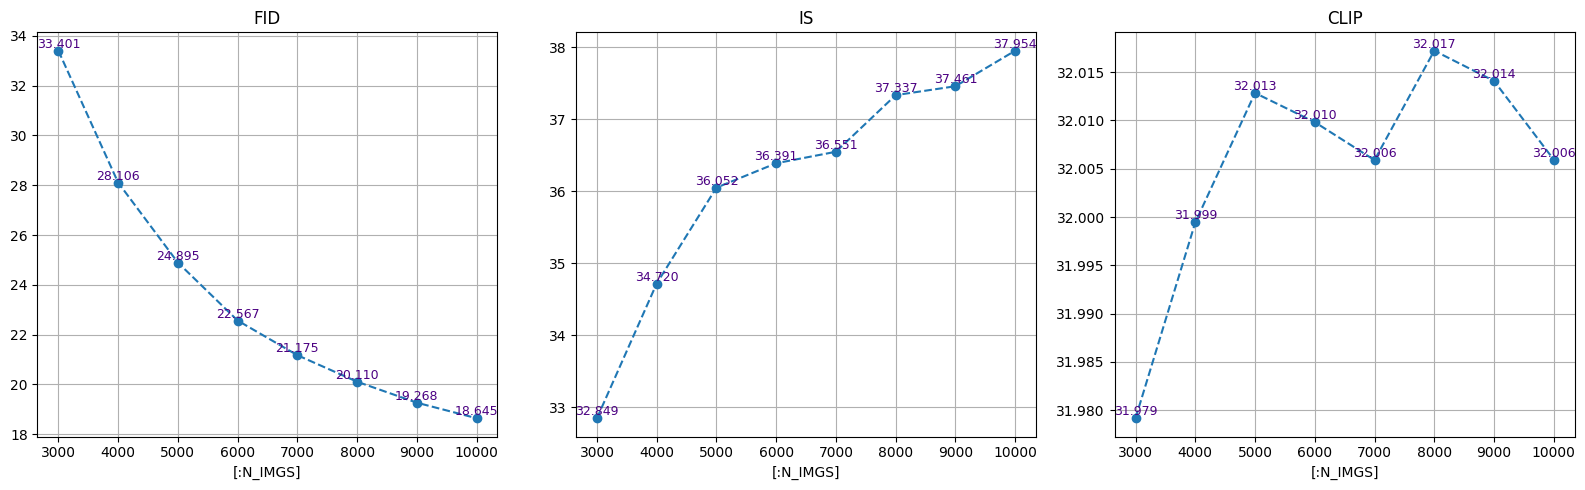

In [3]:
N_IMGS  = list(range(3000, 11000, 1000))
metrics = ['FID', 'IS', 'CLIP']
metrics_list = [[metrics_N[N]['FID'] for N in N_IMGS],
                [metrics_N[N]['IS'] for N in N_IMGS], 
                [metrics_N[N]['CLIP'] for N in N_IMGS]]

import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize=(16, 5))
for m in range(3):
  ax[m].plot(N_IMGS, metrics_list[m], '--o')
  for i, N in enumerate(N_IMGS):
    ax[m].text(N, metrics_list[m][i], f'{metrics_list[m][i]:.3f}', ha='center', va='bottom', fontsize=9, color='indigo')
  ax[m].set_xticks(N_IMGS)
  ax[m].set_xticklabels(N_IMGS)
  ax[m].set_xlabel('[:N_IMGS]')
  ax[m].set_title(metrics[m])
  ax[m].grid(True)

plt.tight_layout();